# Customer Segmentation Model

**Context:** An automobile company has plans to enter new markets with their existing products (P1, P2, P3, P4, and P5). The sales team has classified customers into 4 segments (A, B, C, D) in their existing market. This model will help predict the right segment for new potential customers.

Link to Dataset: [Customer Segmentation Classification](https://www.kaggle.com/datasets/kaushiksuresh147/customer-segmentation?select=Train.csv)

## 1. Import Libraries

In [ ]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("All libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")

All libraries imported successfully!
TensorFlow version: 2.19.0


In [ ]:
df = pd.read_csv('diabetes_dataset.csv')

In [ ]:
#Train Test Split

from sklearn.model_selection import train_test_split

Train, Test = train_test_split(df, test_size=0.20, random_state=2000, stratify=df['diagnosed_diabetes'])



## 2. Load Data

In [ ]:
print(f"Dataset shape: {Train.shape}")
print(f"\nFirst few rows:")
display(Train.head())

print(f"\nDataset Info:")
print(Train.info())

Dataset shape: (80000, 31)

First few rows:


,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
5747,53,Male,Asian,Highschool,Lower-Middle,Employed,Never,1,93,6.0,5.1,6.0,1,1,0,22.3,0.77,128,85,67,139,60,58,124,102,168,17.96,5.97,41.9,Pre-Diabetes,0
51818,55,Female,Asian,No formal,Lower-Middle,Employed,Never,4,42,6.1,7.1,14.6,0,1,0,26.9,0.84,104,66,77,151,54,50,180,112,178,2.00,7.03,34.5,Type 2,1
87259,41,Male,White,Postgraduate,Upper-Middle,Employed,Current,2,52,4.8,6.3,6.7,0,0,0,21.1,0.75,126,69,89,186,58,102,176,95,159,6.43,5.99,25.5,Pre-Diabetes,0
86295,57,Male,Black,Highschool,Lower-Middle,Unemployed,Never,3,63,7.9,6.7,3.5,0,0,0,18.1,0.78,114,70,71,187,46,101,123,113,177,6.16,6.99,26.6,Type 2,1
60718,41,Male,Black,Graduate,Low,Employed,Never,3,74,7.7,5.4,6.1,0,0,0,24.2,0.84,105,75,68,162,66,66,66,100,106,4.37,5.50,22.6,Pre-Diabetes,0



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 80000 entries, 5747 to 11237
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   age                                 80000 non-null  int64  
 1   gender                              80000 non-null  object 
 2   ethnicity                           80000 non-null  object 
 3   education_level                     80000 non-null  object 
 4   income_level                        80000 non-null  object 
 5   employment_status                   80000 non-null  object 
 6   smoking_status                      80000 non-null  object 
 7   alcohol_consumption_per_week        80000 non-null  int64  
 8   physical_activity_minutes_per_week  80000 non-null  int64  
 9   diet_score                          80000 non-null  float64
 10  sleep_hours_per_day                 80000 non-null  float64
 11  screen_time_hours_per_day   

## 3. Exploratory Data Analysis (EDA)

In [ ]:
# Basic statistics
print("\n" + "="*70)
print("DESCRIPTIVE STATISTICS")
print("="*70)
print(Train.describe())

# Check for missing values
print("\n" + "="*70)
print("MISSING VALUES")
print("="*70)
missing = Train.isnull().sum()
missing_pct = (missing / len(Train)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_pct
})
print(missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False))

# Check for duplicates
print(f"\nDuplicate rows: {Train.duplicated().sum()}")


DESCRIPTIVE STATISTICS
               age  alcohol_consumption_per_week  \
count  80000.00000                  80000.000000   
mean      50.13925                      2.004113   
std       15.61112                      1.417831   
min       18.00000                      0.000000   
25%       39.00000                      1.000000   
50%       50.00000                      2.000000   
75%       61.00000                      3.000000   
max       90.00000                     10.000000   

       physical_activity_minutes_per_week    diet_score  sleep_hours_per_day  \
count                        80000.000000  80000.000000         80000.000000   
mean                           118.991825      6.000887             6.997411   
std                             84.318113      1.778944             1.095190   
min                              0.000000      0.000000             3.000000   
25%                             57.000000      4.800000             6.300000   
50%                        

In [ ]:
# Basic statistics
print("\n" + "="*70)
print("DESCRIPTIVE STATISTICS")
print("="*70)
print(Test.describe())

# Check for missing values
print("\n" + "="*70)
print("MISSING VALUES")
print("="*70)
missing = Test.isnull().sum()
missing_pct = (missing / len(Test)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_pct
})
print(missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False))

# Check for duplicates
print(f"\nDuplicate rows: {Test.duplicated().sum()}")


DESCRIPTIVE STATISTICS
                age  alcohol_consumption_per_week  \
count  20000.000000                  20000.000000   
mean      50.045050                      2.001900   
std       15.578654                      1.417603   
min       18.000000                      0.000000   
25%       39.000000                      1.000000   
50%       50.000000                      2.000000   
75%       61.000000                      3.000000   
max       90.000000                      9.000000   

       physical_activity_minutes_per_week    diet_score  sleep_hours_per_day  \
count                        20000.000000  20000.000000         20000.000000   
mean                           118.590900      5.970385             6.999445   
std                             84.776228      1.788810             1.092375   
min                              0.000000      0.000000             3.000000   
25%                             56.000000      4.800000             6.300000   
50%               


TARGET VARIABLE DISTRIBUTION
diagnosed_diabetes
1    47998
0    32002
Name: count, dtype: int64

Percentages:
diagnosed_diabetes
1    59.9975
0    40.0025
Name: proportion, dtype: float64


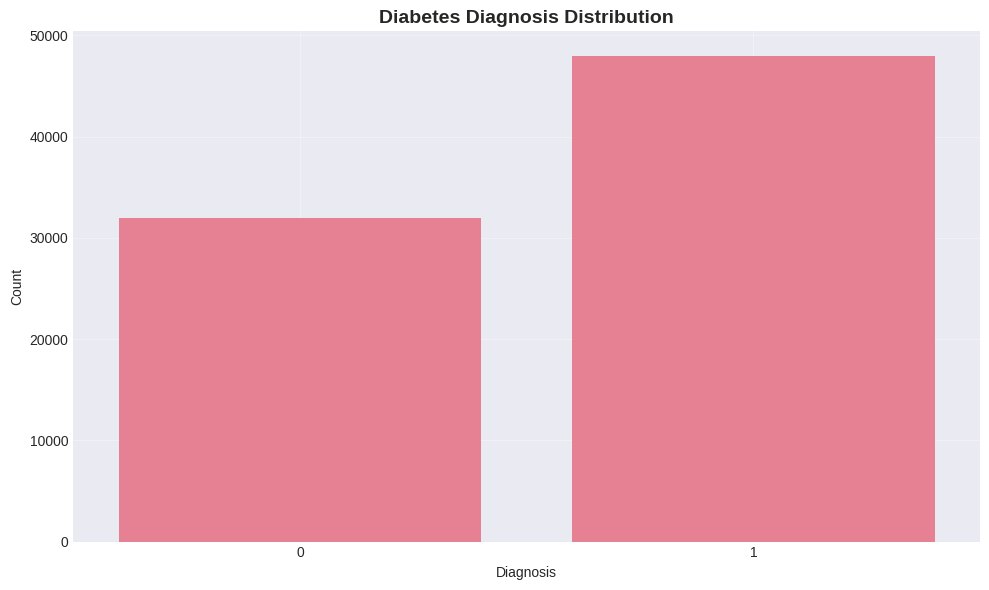

In [ ]:
# Target variable distribution
print("\n" + "="*70)
print("TARGET VARIABLE DISTRIBUTION")
print("="*70)
print(Train['diagnosed_diabetes'].value_counts())
print("\nPercentages:")
print(Train['diagnosed_diabetes'].value_counts(normalize=True) * 100)

# Visualize target distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=Train, x='diagnosed_diabetes', order=sorted(Train['diagnosed_diabetes'].unique()))
plt.title('Diabetes Diagnosis Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Data Preprocessing & Feature Engineering Functions

Create reusable preprocessing functions that can be applied to both train and test data.

In [ ]:
# Store training statistics for test data preprocessing
preprocessing_stats = {}

def preprocess_data(data, is_training=True, stats=None):
    """
    Preprocess data with all transformations.

    Args:
        data: DataFrame to preprocess
        is_training: If True, compute and store statistics. If False, use provided statistics.
        stats: Dictionary of statistics from training data (for test data)

    Returns:
        Preprocessed DataFrame and statistics dictionary
    """
    df_copy = data.copy()

    if is_training:
        stats = {}

    print(f"\n{'='*70}")
    print(f"PREPROCESSING {'TRAINING' if is_training else 'TEST'} DATA")
    print(f"{'='*70}")
    print(f"Starting shape: {df_copy.shape}")

    # Step 2: Feature Engineering
    print("\nStep 2: Feature Engineering...")

    # Age groups
    df_copy['Age_Group'] = pd.cut(
        df_copy['age'],
        bins=[0, 25, 35, 50, 100],
        labels=['Young', 'Adult', 'Middle_Aged', 'Senior']
    )

    # Physical Activity levels
    df_copy['Activity_Level'] = pd.cut(
        df_copy['physical_activity_minutes_per_week'],
        bins=[0, 50, 100, 150, 900],
        labels=['Sedentary', 'Light', 'Active', 'Very_Active']
    )


    # Drug Use
    df_copy['High_DrugUser'] = (
        (df_copy['smoking_status'] == 'Current') &
        (df_copy['alcohol_consumption_per_week'] >= 2)
    ).astype(int)

    print("  ✓ Age_Group")
    print("  ✓ Activity_Level")
    print("  ✓ High_DrugUser")

    print(f"\nFinal shape after preprocessing: {df_copy.shape}")
    print(f"Missing values remaining: {df_copy.isnull().sum().sum()}")

    return df_copy, stats

print("✓ Preprocessing functions defined!")

✓ Preprocessing functions defined!


In [ ]:
# Apply preprocessing to training data
df_processed, preprocessing_stats = preprocess_data(Train, is_training=True)

# Apply the same preprocessing to test data
test_df_processed, _ = preprocess_data(Test, is_training=False, stats=preprocessing_stats)

print("\n" + "="*70)
print("TRAINING & TESTING DATA PREPROCESSING COMPLETE")
print("="*70)


PREPROCESSING TRAINING DATA
Starting shape: (80000, 31)

Step 2: Feature Engineering...
  ✓ Age_Group
  ✓ Activity_Level
  ✓ High_DrugUser

Final shape after preprocessing: (80000, 34)
Missing values remaining: 13

PREPROCESSING TEST DATA
Starting shape: (20000, 31)

Step 2: Feature Engineering...
  ✓ Age_Group
  ✓ Activity_Level
  ✓ High_DrugUser

Final shape after preprocessing: (20000, 34)
Missing values remaining: 1

TRAINING & TESTING DATA PREPROCESSING COMPLETE


In [ ]:
# Encode categorical variables TRAINING ONLY
print("\n" + "="*70)
print("ENCODING CATEGORICAL VARIABLES (TRAINING)")
print("="*70)

# Initialize label encoders dictionary
label_encoders = {}

# Categorical columns to encode (excluding target)
categorical_cols = ['gender', 'ethnicity', 'income_level', 'employment_status', 'education_level',
                   'smoking_status', 'Age_Group', 'Activity_Level', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history']

for col in categorical_cols:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col])
    label_encoders[col] = le
    print(f"✓ Encoded {col}: {len(le.classes_)} unique values")

# Encode target variable separately
target_encoder = LabelEncoder()
df_processed['diagnosed_diabetes'] = target_encoder.fit_transform(df_processed['diagnosed_diabetes'])
print(f"✓ Encoded target variable (diagnosed_diabetes): {target_encoder.classes_}")

print("\nEncoding complete!")
print(f"Final processed shape: {df_processed.shape}")


ENCODING CATEGORICAL VARIABLES (TRAINING)
✓ Encoded gender: 3 unique values
✓ Encoded ethnicity: 5 unique values
✓ Encoded income_level: 5 unique values
✓ Encoded employment_status: 4 unique values
✓ Encoded education_level: 4 unique values
✓ Encoded smoking_status: 3 unique values
✓ Encoded Age_Group: 4 unique values
✓ Encoded Activity_Level: 5 unique values
✓ Encoded family_history_diabetes: 2 unique values
✓ Encoded hypertension_history: 2 unique values
✓ Encoded cardiovascular_history: 2 unique values
✓ Encoded target variable (diagnosed_diabetes): [0 1]

Encoding complete!
Final processed shape: (80000, 34)


In [ ]:
# Encode test data categorical variables using TRAINING encoders
print("\n" + "="*70)
print("ENCODING TEST DATA CATEGORICAL VARIABLES")
print("="*70)

for col in categorical_cols:
    le = label_encoders[col]

    # Handle unseen categories by mapping them to a default value
    # Create a mapping with -1 for unknown categories
    test_df_processed[col] = test_df_processed[col].apply(
        lambda x: le.transform([x])[0] if x in le.classes_ else -1
    )

    # Check for unknown categories
    unknown_count = (test_df_processed[col] == -1).sum()
    if unknown_count > 0:
        # Map unknowns to the most common category from training
        most_common = 0  # Use the first encoded value as default
        test_df_processed.loc[test_df_processed[col] == -1, col] = most_common
        print(f"✓ Encoded {col} ({unknown_count} unknown categories mapped to default)")
    else:
        print(f"✓ Encoded {col}")

print("\nTest data encoding complete!")
print(f"Encoded test data shape: {test_df_processed.shape}")


ENCODING TEST DATA CATEGORICAL VARIABLES
✓ Encoded gender
✓ Encoded ethnicity
✓ Encoded income_level
✓ Encoded employment_status
✓ Encoded education_level
✓ Encoded smoking_status
✓ Encoded Age_Group
✓ Encoded Activity_Level
✓ Encoded family_history_diabetes
✓ Encoded hypertension_history
✓ Encoded cardiovascular_history

Test data encoding complete!
Encoded test data shape: (20000, 34)


## 5. Split Features and Target


In [ ]:
# Separate features and target
X = df_processed.drop(['diagnosed_diabetes', 'diabetes_stage'], axis=1)
y = df_processed['diagnosed_diabetes']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeatures:", X.columns.tolist())
print("\nTarget classes:", np.unique(y))
print("Target class names:", target_encoder.classes_)

# Prepare test features
X_test = test_df_processed.drop(['diagnosed_diabetes', 'diabetes_stage'], axis=1)
y_test = test_df_processed['diagnosed_diabetes']
# Verify feature alignment
print("\n" + "="*70)
print("FEATURE ALIGNMENT CHECK")
print("="*70)
print(f"Training features: {X.shape[1]}")
print(f"Test features: {X_test.shape[1]}")

# Ensure same column order
X_test = X_test[X.columns]

print("\n✓ Feature alignment verified!")
print(f"Columns match: {list(X.columns) == list(X_test.columns)}")

Features shape: (80000, 32)
Target shape: (80000,)

Features: ['age', 'gender', 'ethnicity', 'education_level', 'income_level', 'employment_status', 'smoking_status', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides', 'glucose_fasting', 'glucose_postprandial', 'insulin_level', 'hba1c', 'diabetes_risk_score', 'Age_Group', 'Activity_Level', 'High_DrugUser']

Target classes: [0 1]
Target class names: [0 1]

FEATURE ALIGNMENT CHECK
Training features: 32
Test features: 32

✓ Feature alignment verified!
Columns match: True


## 6. Train-Validation Split

In [ ]:
# Split into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape)
print("Validation set size:", X_val.shape)

print("\nTarget distribution in training set:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nTarget distribution in validation set:")
print(pd.Series(y_val).value_counts().sort_index())

Training set size: (64000, 32)
Validation set size: (16000, 32)

Target distribution in training set:
diagnosed_diabetes
0    25602
1    38398
Name: count, dtype: int64

Target distribution in validation set:
diagnosed_diabetes
0    6400
1    9600
Name: count, dtype: int64


## 7. Feature Scaling

In [ ]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print("Features scaled successfully!")
print(f"\nScaled training set shape: {X_train_scaled.shape}")
print(f"Scaled validation set shape: {X_val_scaled.shape}")

Features scaled successfully!

Scaled training set shape: (64000, 32)
Scaled validation set shape: (16000, 32)


In [ ]:
# Scale test data using training scaler
X_test_scaled = scaler.transform(X_test)
print(f"\n✓ Test data scaled using training scaler")
print(f"Scaled test data shape: {X_test_scaled.shape}")


✓ Test data scaled using training scaler
Scaled test data shape: (20000, 32)


## 8. Baseline Model: Logistic Regression

In [ ]:
# Train baseline Logistic Regression
print("\n" + "="*70)
print("BASELINE MODEL: LOGISTIC REGRESSION")
print("="*70)

lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    multi_class='multinomial'
)

lr_model.fit(X_train_scaled, y_train)

# Predictions
y_val_pred_lr = lr_model.predict(X_val_scaled)

# Evaluate
val_accuracy_lr = accuracy_score(y_val, y_val_pred_lr)
val_precision_lr = precision_score(y_val, y_val_pred_lr, average='weighted')
val_recall_lr = recall_score(y_val, y_val_pred_lr, average='weighted')
val_f1_lr = f1_score(y_val, y_val_pred_lr, average='weighted')

print(f"\nValidation Set Performance:")
print(f"  Accuracy:  {val_accuracy_lr:.4f}")
print(f"  Precision: {val_precision_lr:.4f}")
print(f"  Recall:    {val_recall_lr:.4f}")
print(f"  F1-Score:  {val_f1_lr:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_val,
    y_val_pred_lr
)) # removed target names parameter because there was an error about target names being integer datatype instead of string.


BASELINE MODEL: LOGISTIC REGRESSION

Validation Set Performance:
  Accuracy:  0.8598
  Precision: 0.8594
  Recall:    0.8598
  F1-Score:  0.8595

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.81      0.82      6400
           1       0.88      0.89      0.88      9600

    accuracy                           0.86     16000
   macro avg       0.85      0.85      0.85     16000
weighted avg       0.86      0.86      0.86     16000



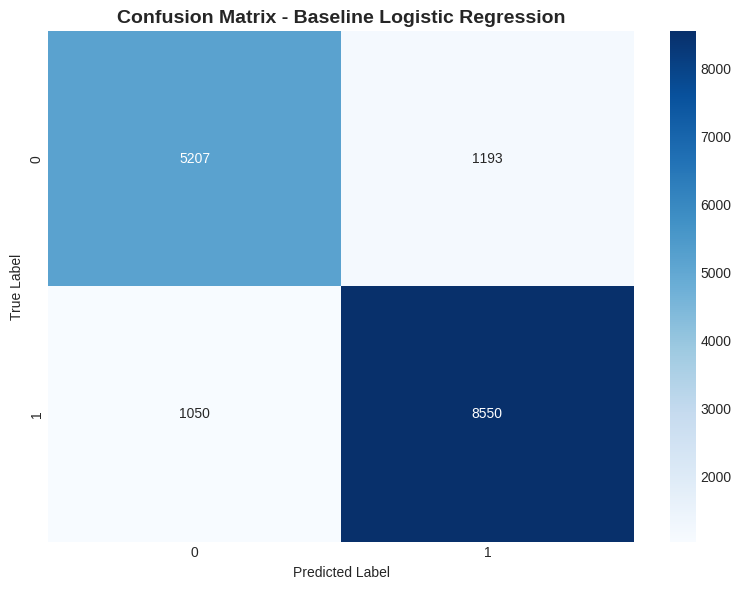

In [ ]:
# Confusion Matrix for Baseline LR
cm_lr = confusion_matrix(y_val, y_val_pred_lr)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=target_encoder.classes_,
    yticklabels=target_encoder.classes_
)
plt.title('Confusion Matrix - Baseline Logistic Regression', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## 9. Hyperparameter Tuning: Grid Search (Will help improve model)

In [ ]:
# Ran this but didn't improve the model


# # Define parameter grid
# param_grid = {
#     'C': [0.01, 0.1, 1, 10, 100],
#     'penalty': ['l1', 'l2'],
#     'solver': ['saga'],
#     'max_iter': [1000]
# }

# print("\n" + "="*70)
# print("HYPERPARAMETER TUNING: GRID SEARCH")
# print("="*70)
# print(f"\nParameter grid: {param_grid}")
# print("\nRunning Grid Search... (this may take a few minutes)")

# # Grid Search
# grid_search = GridSearchCV(
#     LogisticRegression(random_state=42, multi_class='multinomial'),
#     param_grid,
#     cv=5,
#     scoring='accuracy',
#     n_jobs=-1,
#     verbose=1
# )

# grid_search.fit(X_train_scaled, y_train)

# print(f"\nBest parameters: {grid_search.best_params_}")
# print(f"Best CV score: {grid_search.best_score_:.4f}")

# # Get best model
# best_lr_model = grid_search.best_estimator_

# # Evaluate on validation set
# y_val_pred_best = best_lr_model.predict(X_val_scaled)

# val_accuracy_best = accuracy_score(y_val, y_val_pred_best)
# val_precision_best = precision_score(y_val, y_val_pred_best, average='weighted')
# val_recall_best = recall_score(y_val, y_val_pred_best, average='weighted')
# val_f1_best = f1_score(y_val, y_val_pred_best, average='weighted')

# print(f"\nValidation Set Performance (Tuned Model):")
# print(f"  Accuracy:  {val_accuracy_best:.4f}")
# print(f"  Precision: {val_precision_best:.4f}")
# print(f"  Recall:    {val_recall_best:.4f}")
# print(f"  F1-Score:  {val_f1_best:.4f}")

# print(f"\nImprovement over baseline: {(val_accuracy_best - val_accuracy_lr)*100:.2f}%")

print("\n" + "="*70)
print("MODEL 8: HYPERPARAMETER TUNING FOR LOGISTIC REGRESSION")
print("="*70)

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Define parameter grid for Logistic Regression
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],     # Regularization strength
    'penalty': ['l1', 'l2'],          # L1 or L2 regularization
    'solver': ['saga'],               # Only solver that supports both L1/L2 + multinomial
    'max_iter': [2000]                # Ensure convergence
}

print(f"\nParameter Grid:\n{param_grid}")
print("\nRunning Grid Search (this may take a few minutes)...")

# Initialize GridSearchCV
grid_search = GridSearchCV(
    LogisticRegression(
        random_state=42,
        multi_class='multinomial'
    ),
    param_grid=param_grid,
    cv=5,                   # 5-fold cross validation
    scoring='accuracy',     # Evaluate models using accuracy
    n_jobs=-1,              # Use all CPU cores
    verbose=1
)

# Fit grid search on scaled training data
grid_search.fit(X_train_scaled, y_train)

# Results
print("\n" + "="*50)
print("GRID SEARCH RESULTS")
print("="*50)
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validated Accuracy: {grid_search.best_score_:.4f}")

# Best logistic regression model returned by GridSearchCV
best_lr_model = grid_search.best_estimator_

# Predict on validation set
y_val_pred_best = best_lr_model.predict(X_val_scaled)

# Evaluate tuned logistic regression model
val_accuracy_best = accuracy_score(y_val, y_val_pred_best)
val_precision_best = precision_score(y_val, y_val_pred_best, average='weighted')
val_recall_best = recall_score(y_val, y_val_pred_best, average='weighted')
val_f1_best = f1_score(y_val, y_val_pred_best, average='weighted')

print("\nValidation Set Performance (Tuned Logistic Regression):")
print(f"  Accuracy:  {val_accuracy_best:.4f}")
print(f"  Precision: {val_precision_best:.4f}")
print(f"  Recall:    {val_recall_best:.4f}")
print(f"  F1-Score:  {val_f1_best:.4f}")

print(f"\nImprovement Over Baseline LR: {(val_accuracy_best - val_accuracy_lr)*100:.2f}%")



MODEL 8: HYPERPARAMETER TUNING FOR LOGISTIC REGRESSION

Parameter Grid:
{'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l1', 'l2'], 'solver': ['saga'], 'max_iter': [2000]}

Running Grid Search (this may take a few minutes)...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

GRID SEARCH RESULTS
Best Parameters: {'C': 0.1, 'max_iter': 2000, 'penalty': 'l1', 'solver': 'saga'}
Best Cross-Validated Accuracy: 0.8596

Validation Set Performance (Tuned Logistic Regression):
  Accuracy:  0.8597
  Precision: 0.8593
  Recall:    0.8597
  F1-Score:  0.8594

Improvement Over Baseline LR: -0.01%


## 10. Neural Network Model

In [ ]:
# Build Neural Network
print("\n" + "="*70)
print("NEURAL NETWORK MODEL")
print("="*70)

def build_model(input_dim, num_classes):
    # To improve accuracy look into dropout and batch normalization
    model = keras.Sequential([
        layers.Dense(128, activation='relu', input_dim=input_dim),

        layers.Dense(64, activation='relu'),

        layers.Dense(32, activation='relu'),

        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Create model
nn_model = build_model(X_train_scaled.shape[1], len(np.unique(y)))

print("\nModel Architecture:")
nn_model.summary()

# Train model
print("\nTraining Neural Network...")
history = nn_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    verbose=1
)


NEURAL NETWORK MODEL

Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,626 (57.13 KB)

 Trainable params: 14,626 (57.13 KB)

 Non-trainable params: 0 (0.00 B)


Training Neural Network...
Epoch 1/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8595 - loss: 0.3203 - val_accuracy: 0.8968 - val_loss: 0.2554
Epoch 2/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9037 - loss: 0.2406 - val_accuracy: 0.9053 - val_loss: 0.2403
Epoch 3/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9118 - loss: 0.2273 - val_accuracy: 0.9093 - val_loss: 0.2334
Epoch 4/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9148 - loss: 0.2215 - val_accuracy: 0.9093 - val_loss: 0.2325
Epoch 5/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9168 - loss: 0.2174 - val_accuracy: 0.9106 - val_loss: 0.2294
Epoch 6/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9183 - loss: 0.2150 - val_accuracy: 0.9100 - val_loss: 0.2318
Epoch 7/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9185 - loss: 0.2129 - val_accuracy: 0.9110 - val_loss: 0.2311
Epoch 8/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step 

In [ ]:
# Evaluate basline NN
y_val_pred_nn = np.argmax(nn_model.predict(X_val_scaled), axis=1)

nn_accuracy = accuracy_score(y_val, y_val_pred_nn)
nn_precision = precision_score(y_val, y_val_pred_nn, average='weighted')
nn_recall = recall_score(y_val, y_val_pred_nn, average='weighted')
nn_f1 = f1_score(y_val, y_val_pred_nn, average='weighted')

print(f"\nValidation Set Performance:")
print(f"  Accuracy:  {nn_accuracy:.4f}")
print(f"  Precision: {nn_precision:.4f}")
print(f"  Recall:    {nn_recall:.4f}")
print(f"  F1-Score:  {nn_f1:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_val,
    y_val_pred_nn
))

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

Validation Set Performance:
  Accuracy:  0.8714
  Precision: 0.8725
  Recall:    0.8714
  F1-Score:  0.8718

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.84      6400
           1       0.90      0.88      0.89      9600

    accuracy                           0.87     16000
   macro avg       0.86      0.87      0.87     16000
weighted avg       0.87      0.87      0.87     16000



## 11. Training Visualization

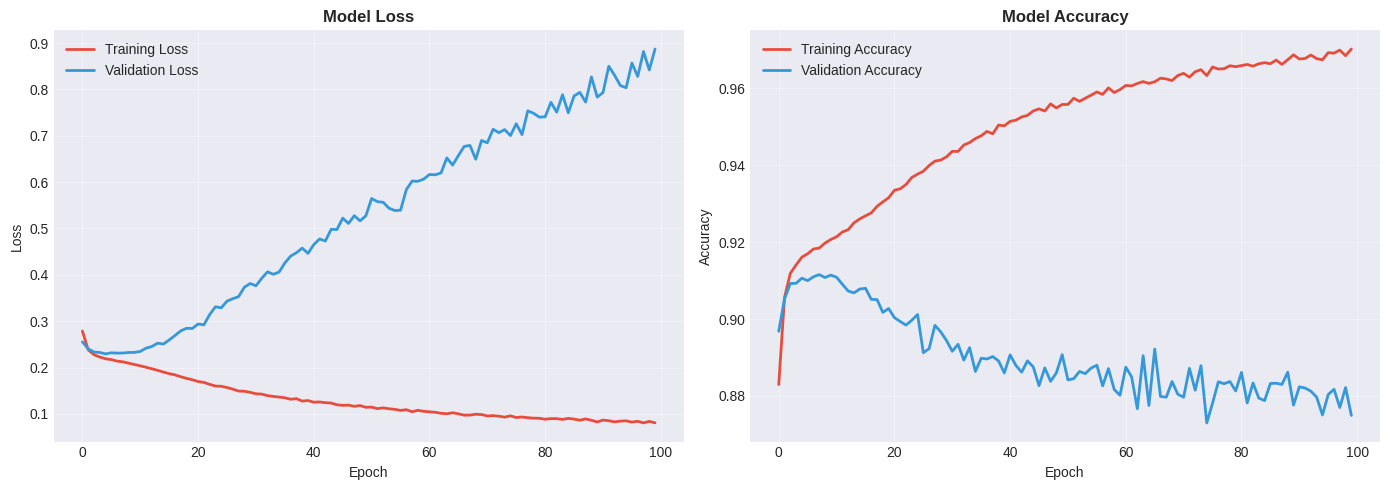


Training completed in 100 epochs
Best validation loss: 0.2294
Best validation accuracy: 0.9116


In [ ]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2, color='#e74c3c')
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2, color='#3498db')
axes[0].set_title('Model Loss', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2, color='#e74c3c')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2, color='#3498db')
axes[1].set_title('Model Accuracy', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nTraining completed in {len(history.history['loss'])} epochs")
print(f"Best validation loss: {min(history.history['val_loss']):.4f}")
print(f"Best validation accuracy: {max(history.history['val_accuracy']):.4f}")

## 12. Model Comparison


MODEL COMPARISON
                         Model  Accuracy  Precision   Recall  F1-Score
Logistic Regression (Baseline)  0.859812   0.859407 0.859812  0.859539
                Neural Network  0.871375   0.872539 0.871375  0.871750


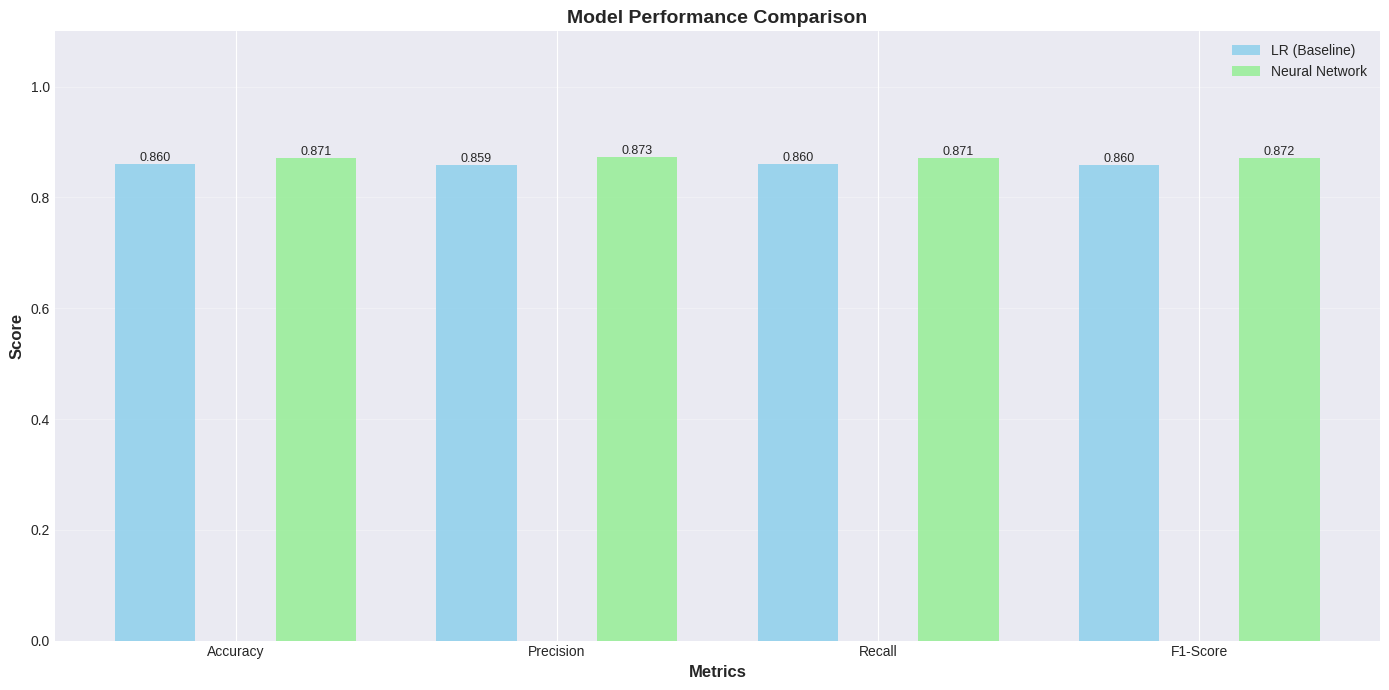

In [ ]:
# Compare models
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression (Baseline)', 'Neural Network'],
    'Accuracy': [val_accuracy_lr, nn_accuracy],
    'Precision': [val_precision_lr, nn_precision],
    'Recall': [val_recall_lr, nn_recall],
    'F1-Score': [val_f1_lr, nn_f1]
})

print("\n" + "="*70)
print("MODEL COMPARISON")
print("="*70)
print(comparison_df.to_string(index=False))

# Visualize comparison
fig, ax = plt.subplots(figsize=(14, 7))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics))
width = 0.25

lr_values = [val_accuracy_lr, val_precision_lr, val_recall_lr, val_f1_lr]
nn_values = [nn_accuracy, nn_precision, nn_recall, nn_f1]

bars1 = ax.bar(x - width, lr_values, width, label='LR (Baseline)', alpha=0.8, color='skyblue')
bars3 = ax.bar(x + width, nn_values, width, label='Neural Network', alpha=0.8, color='lightgreen')

ax.set_xlabel('Metrics', fontweight='bold', fontsize=12)
ax.set_ylabel('Score', fontweight='bold', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, 1.1])

# Add value labels on bars
for bars in [bars1, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 13. Process Test Data and Make Predictions

In [ ]:
# Decide best model
best_model_name = 'Neural Network' if nn_accuracy > val_accuracy_lr else 'Logistic Regression'

print("\n" + "="*70)
print(f"MAKING PREDICTIONS USING {best_model_name.upper()}")
print("="*70)

if nn_accuracy > val_accuracy_lr:
    # Use Neural Network
    test_predictions_encoded = np.argmax(nn_model.predict(X_test_scaled, verbose=0), axis=1)
else:
    # Use Logistic Regression
    test_predictions_encoded = lr_model.predict(X_test_scaled)

# Decode predictions to original segment labels
test_predictions = target_encoder.inverse_transform(test_predictions_encoded)


test_accuracy = accuracy_score(y_test, test_predictions)
print(f"\nAccuracy on test data: {test_accuracy:.4f}")

# If this is multi-class, use macro/weighted
test_precision = precision_score(y_test, test_predictions, average='weighted')
test_recall = recall_score(y_test, test_predictions, average='weighted')
test_f1 = f1_score(y_test, test_predictions, average='weighted')

print(f"Precision (weighted): {test_precision:.4f}")
print(f"Recall (weighted):    {test_recall:.4f}")
print(f"F1-score (weighted):  {test_f1:.4f}")

# Optional: full per-class view
print("\nDetailed report:")
print(classification_report(y_test, test_predictions))


MAKING PREDICTIONS USING NEURAL NETWORK

Accuracy on test data: 0.8749
Precision (weighted): 0.8761
Recall (weighted):    0.8749
F1-score (weighted):  0.8753

Detailed report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.85      8000
           1       0.91      0.88      0.89     12000

    accuracy                           0.87     20000
   macro avg       0.87      0.87      0.87     20000
weighted avg       0.88      0.87      0.88     20000



In [ ]:
## IMPROVING THE MODEL

In [ ]:
# MODEL 2 - Added learning epochs

print("\n" + "="*70)
print("MODEL 2: NEURAL NETWORK WITH MORE LEARNING EPOCHS")
print("="*70)

def build_model2(input_dim, num_classes):
    model = keras.Sequential([
        layers.Dense(128, activation='relu', input_dim=input_dim),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Train for more epochs (baseline = 100 → new = 150)
nn_model2 = build_model2(X_train_scaled.shape[1], len(np.unique(y)))

print("\nTraining Model 2 with 150 epochs...")
history2 = nn_model2.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=200,
    batch_size=32,
    verbose=1
)

# Evaluate
y_val_pred_nn2 = np.argmax(nn_model2.predict(X_val_scaled), axis=1)

nn2_accuracy = accuracy_score(y_val, y_val_pred_nn2)
nn2_precision = precision_score(y_val, y_val_pred_nn2, average='weighted')
nn2_recall = recall_score(y_val, y_val_pred_nn2, average='weighted')
nn2_f1 = f1_score(y_val, y_val_pred_nn2, average='weighted')

print(f"\nValidation Set Performance (Model 2):")
print(f"  Accuracy:  {nn2_accuracy:.4f}")
print(f"  Precision: {nn2_precision:.4f}")
print(f"  Recall:    {nn2_recall:.4f}")
print(f"  F1-Score:  {nn2_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_nn2))



MODEL 2: NEURAL NETWORK WITH MORE LEARNING EPOCHS

Training Model 2 with 150 epochs...
Epoch 1/200
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8591 - loss: 0.3213 - val_accuracy: 0.9003 - val_loss: 0.2528
Epoch 2/200
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9047 - loss: 0.2409 - val_accuracy: 0.9079 - val_loss: 0.2363
Epoch 3/200
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9099 - loss: 0.2293 - val_accuracy: 0.9086 - val_loss: 0.2339
Epoch 4/200
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9156 - loss: 0.2196 - val_accuracy: 0.9078 - val_loss: 0.2374
Epoch 5/200
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9144 - loss: 0.2205 - val_accuracy: 0.9099 - val_loss: 0.2330
Epoch 6/200
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9165 - loss: 0.2167 - val_accuracy: 0.9107 - val_loss: 0.2312
Epoch 7/200
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9186 - loss: 0.2124 - val_accuracy: 0.9117 - val_loss: 0.

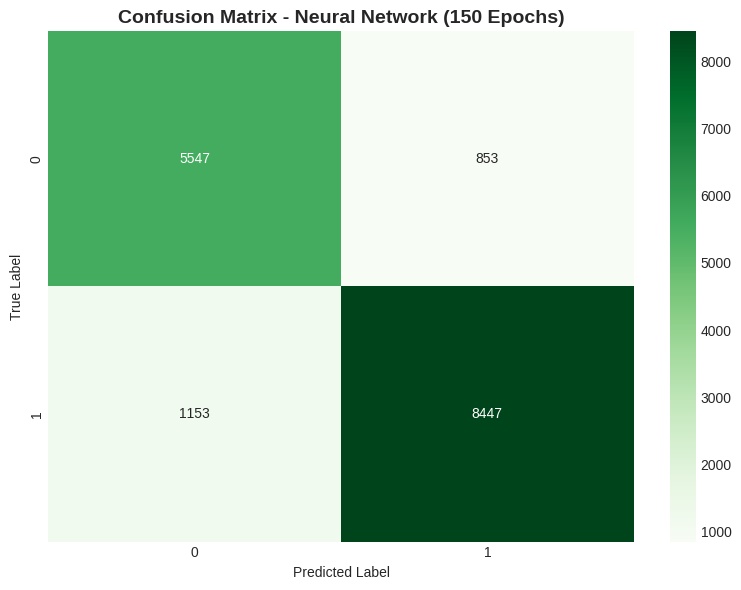

In [ ]:
# Confusion matrix model 2
cm_nn2 = confusion_matrix(y_val, y_val_pred_nn2)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_nn2,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=target_encoder.classes_,
    yticklabels=target_encoder.classes_
)
plt.title('Confusion Matrix - Neural Network (150 Epochs)', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()


In [ ]:
# Improving the model -- adding new nodes

print("\n" + "="*70)
print("MODEL 3: NN WITH MORE NODES")
print("="*70)

def build_model3(input_dim, num_classes):
    model = keras.Sequential([
        # Increase the number of neurons in each layer
        layers.Dense(256, activation='relu', input_dim=input_dim),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Build and train model
nn_model3 = build_model3(X_train_scaled.shape[1], len(np.unique(y)))

print("\nTraining Model 3 with more hidden nodes...")
history3 = nn_model3.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    verbose=1
)


# Evaluate on test data
y_val_pred_nn3 = np.argmax(nn_model3.predict(X_val_scaled), axis=1)

nn3_accuracy = accuracy_score(y_val, y_val_pred_nn3)
nn3_precision = precision_score(y_val, y_val_pred_nn3, average='weighted')
nn3_recall = recall_score(y_val, y_val_pred_nn3, average='weighted')
nn3_f1 = f1_score(y_val, y_val_pred_nn3, average='weighted')

print(f"\nValidation Set Performance (Model 3):")
print(f"  Accuracy:  {nn3_accuracy:.4f}")
print(f"  Precision: {nn3_precision:.4f}")
print(f"  Recall:    {nn3_recall:.4f}")
print(f"  F1-Score:  {nn3_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_nn3))






MODEL 3: NEURAL NETWORK WITH MORE HIDDEN NODES

Training Model 3 with more hidden nodes...
Epoch 1/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8687 - loss: 0.3048 - val_accuracy: 0.8986 - val_loss: 0.2506
Epoch 2/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9072 - loss: 0.2348 - val_accuracy: 0.9094 - val_loss: 0.2339
Epoch 3/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9129 - loss: 0.2256 - val_accuracy: 0.9094 - val_loss: 0.2351
Epoch 4/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9160 - loss: 0.2185 - val_accuracy: 0.9090 - val_loss: 0.2319
Epoch 5/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9174 - loss: 0.2164 - val_accuracy: 0.9102 - val_loss: 0.2297
Epoch 6/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9166 - loss: 0.2178 - val_accuracy: 0.9113 - val_loss: 0.2302
Epoch 7/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9178 - loss: 0.2137 - val_accuracy: 0.9110 - val_loss

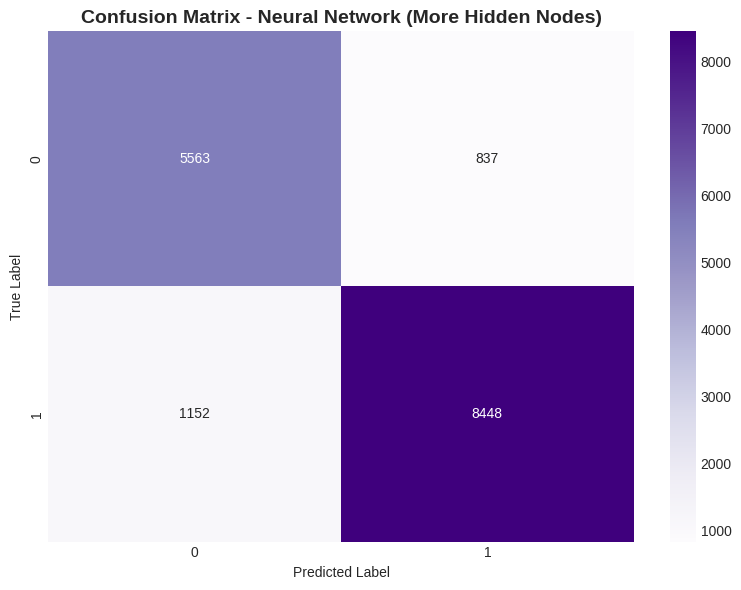

In [ ]:
#Classification matrix

cm_nn3 = confusion_matrix(y_val, y_val_pred_nn3)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_nn3,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=target_encoder.classes_,
    yticklabels=target_encoder.classes_
)
plt.title('Confusion Matrix - Neural Network (More Hidden Nodes)', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()


In [ ]:
# model 4: combining both model 2 epochs and model 3 nodes

print("\n" + "="*70)
print("MODEL 4: NEURAL NETWORK WITH MORE NODES + MORE EPOCHS")
print("="*70)

def build_model4(input_dim, num_classes):
    model = keras.Sequential([
        layers.Dense(256, activation='relu', input_dim=input_dim),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Build and train Model 4
nn_model4 = build_model4(X_train_scaled.shape[1], len(np.unique(y)))

print("\nNN with more hidden nodes + epochs...")
history4 = nn_model4.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=200,
    batch_size=32,
    verbose=1
)



MODEL 4: NEURAL NETWORK WITH MORE NODES + MORE EPOCHS

Training Model 4 with more hidden nodes and 150 epochs...
Epoch 1/200
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8682 - loss: 0.3052 - val_accuracy: 0.9022 - val_loss: 0.2438
Epoch 2/200
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9056 - loss: 0.2369 - val_accuracy: 0.9079 - val_loss: 0.2352
Epoch 3/200
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9119 - loss: 0.2266 - val_accuracy: 0.9091 - val_loss: 0.2326
Epoch 4/200
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9153 - loss: 0.2208 - val_accuracy: 0.9099 - val_loss: 0.2332
Epoch 5/200
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9159 - loss: 0.2184 - val_accuracy: 0.9098 - val_loss: 0.2321
Epoch 6/200
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9194 - loss: 0.2132 - val_accuracy: 0.9114 - val_loss: 0.2306
Epoch 7/200
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9183 - loss: 0.2137 - val_accur

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

Validation Set Performance (Model 4):
  Accuracy:  0.8622
  Precision: 0.8625
  Recall:    0.8622
  F1-Score:  0.8623

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.83      0.83      6400
           1       0.89      0.88      0.88      9600

    accuracy                           0.86     16000
   macro avg       0.86      0.86      0.86     16000
weighted avg       0.86      0.86      0.86     16000



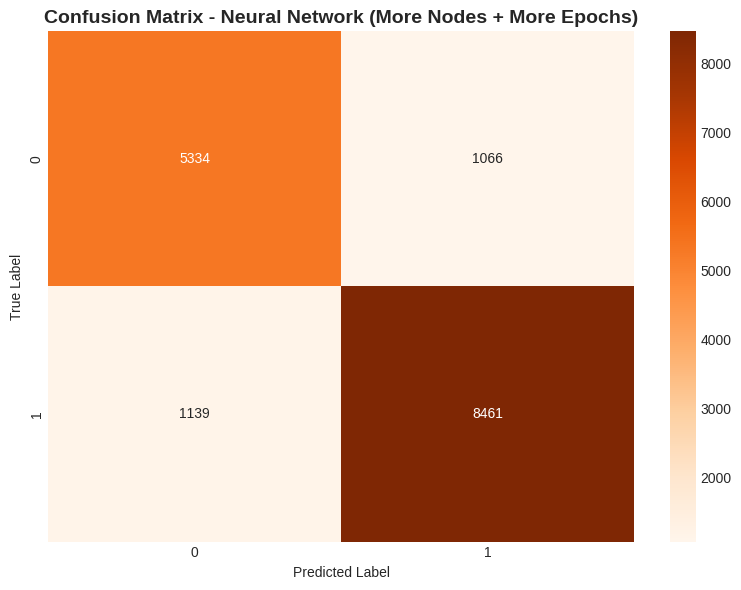

In [ ]:
# Evaluate
y_val_pred_nn4 = np.argmax(nn_model4.predict(X_val_scaled), axis=1)

nn4_accuracy = accuracy_score(y_val, y_val_pred_nn4)
nn4_precision = precision_score(y_val, y_val_pred_nn4, average='weighted')
nn4_recall = recall_score(y_val, y_val_pred_nn4, average='weighted')
nn4_f1 = f1_score(y_val, y_val_pred_nn4, average='weighted')

print(f"\nValidation Set Performance (Model 4):")
print(f"  Accuracy:  {nn4_accuracy:.4f}")
print(f"  Precision: {nn4_precision:.4f}")
print(f"  Recall:    {nn4_recall:.4f}")
print(f"  F1-Score:  {nn4_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_nn4))


# confusion matrix 4
cm_nn4 = confusion_matrix(y_val, y_val_pred_nn4)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_nn4,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=target_encoder.classes_,
    yticklabels=target_encoder.classes_
)
plt.title('Confusion Matrix - Neural Network (More Nodes + More Epochs)', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()



In [ ]:
# Improving Predictions - layered activation function change

print("\n" + "="*70)
print("MODEL 5: NEURAL NETWORK WITH tanh + ReLU ACTIVATIONS")
print("="*70)

def build_model5(input_dim, num_classes):
    model = keras.Sequential([
        layers.Dense(256, activation='tanh', input_dim=input_dim),
        layers.Dense(128, activation='tanh'),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Build and train Model 5
nn_model5 = build_model5(X_train_scaled.shape[1], len(np.unique(y)))

print("\nTraining Model 5 (Hybrid tanh + ReLU)...")
history5 = nn_model5.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=150,          # keep same epoch count as Model 4 for fair comparison
    batch_size=32,
    verbose=1
)



MODEL 5: NEURAL NETWORK WITH tanh + ReLU ACTIVATIONS

Training Model 5 (Hybrid tanh + ReLU)...
Epoch 1/150
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8782 - loss: 0.2910 - val_accuracy: 0.9046 - val_loss: 0.2430
Epoch 2/150
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9065 - loss: 0.2367 - val_accuracy: 0.9103 - val_loss: 0.2355
Epoch 3/150
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9100 - loss: 0.2299 - val_accuracy: 0.9087 - val_loss: 0.2333
Epoch 4/150
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9130 - loss: 0.2258 - val_accuracy: 0.9112 - val_loss: 0.2301
Epoch 5/150
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9133 - loss: 0.2241 - val_accuracy: 0.9140 - val_loss: 0.2246
Epoch 6/150
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9163 - loss: 0.2187 - val_accuracy: 0.9118 - val_loss: 0.2267
Epoch 7/150
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9151 - loss: 0.2201 - val_accuracy: 0.9137 - val_

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

Validation Set Performance (Model 5):
  Accuracy:  0.8792
  Precision: 0.8811
  Recall:    0.8792
  F1-Score:  0.8797

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.88      0.85      6400
           1       0.91      0.88      0.90      9600

    accuracy                           0.88     16000
   macro avg       0.87      0.88      0.88     16000
weighted avg       0.88      0.88      0.88     16000



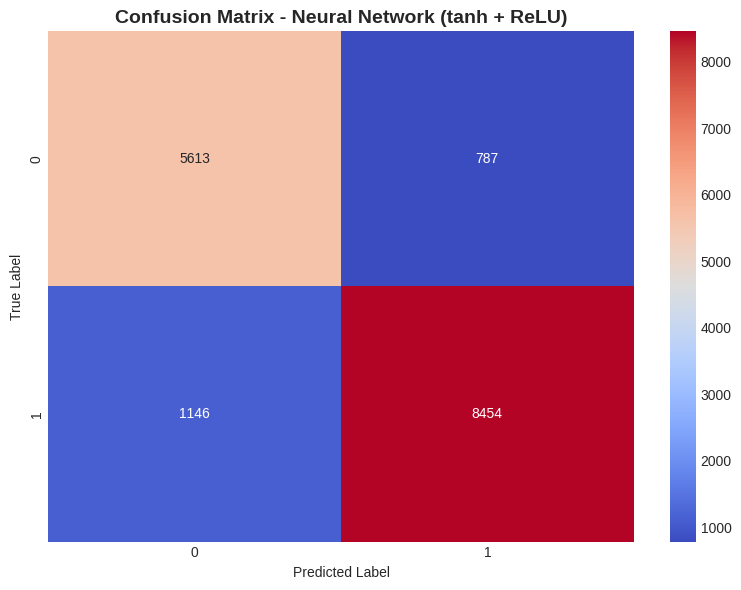

In [ ]:
# Evaluate validation performance for model 5 - increased basline results a bit
y_val_pred_nn5 = np.argmax(nn_model5.predict(X_val_scaled), axis=1)

nn5_accuracy  = accuracy_score(y_val, y_val_pred_nn5)
nn5_precision = precision_score(y_val, y_val_pred_nn5, average='weighted')
nn5_recall    = recall_score(y_val, y_val_pred_nn5, average='weighted')
nn5_f1        = f1_score(y_val, y_val_pred_nn5, average='weighted')

print(f"\nValidation Set Performance (Model 5):")
print(f"  Accuracy:  {nn5_accuracy:.4f}")
print(f"  Precision: {nn5_precision:.4f}")
print(f"  Recall:    {nn5_recall:.4f}")
print(f"  F1-Score:  {nn5_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_nn5))

# confusion matrix
cm_nn5 = confusion_matrix(y_val, y_val_pred_nn5)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_nn5,
    annot=True,
    fmt='d',
    cmap='coolwarm',
    xticklabels=target_encoder.classes_,
    yticklabels=target_encoder.classes_
)
plt.title('Confusion Matrix - Neural Network (tanh + ReLU)', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()


In [ ]:
# Improving predictions -- changed the optimizer function to RMSprop

print("\n" + "="*70)
print("MODEL 7: NEURAL NETWORK WITH RMSprop OPTIMIZER")
print("="*70)

from tensorflow.keras.optimizers import RMSprop

def build_model7(input_dim, num_classes):
    model = keras.Sequential([
        layers.Dense(256, activation='relu', input_dim=input_dim),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=RMSprop(learning_rate=0.001), # found RMSprop while looking into what Adam could be changed with and gave it a try
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

nn_model7 = build_model7(X_train_scaled.shape[1], len(np.unique(y)))

print("\nTraining Model 7 (RMSprop)...")
history7 = nn_model7.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=150,
    batch_size=32,
    verbose=1
)
#evaluate
y_val_pred_nn7 = np.argmax(nn_model7.predict(X_val_scaled), axis=1)

nn7_accuracy  = accuracy_score(y_val, y_val_pred_nn7)
nn7_precision = precision_score(y_val, y_val_pred_nn7, average='weighted')
nn7_recall    = recall_score(y_val, y_val_pred_nn7, average='weighted')
nn7_f1        = f1_score(y_val, y_val_pred_nn7, average='weighted')

print(f"\nValidation Set Performance (Model 7):")
print(f"  Accuracy:  {nn7_accuracy:.4f}")
print(f"  Precision: {nn7_precision:.4f}")
print(f"  Recall:    {nn7_recall:.4f}")
print(f"  F1-Score:  {nn7_f1:.4f}")

print("\nClassification Report — Model 7 (RMSprop):")
print(classification_report(y_val, y_val_pred_nn7))



MODEL 7: NEURAL NETWORK WITH RMSprop OPTIMIZER

Training Model 7 (RMSprop)...
Epoch 1/150
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8732 - loss: 0.2978 - val_accuracy: 0.9010 - val_loss: 0.2478
Epoch 2/150
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9060 - loss: 0.2380 - val_accuracy: 0.9072 - val_loss: 0.2388
Epoch 3/150
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9093 - loss: 0.2321 - val_accuracy: 0.9086 - val_loss: 0.2359
Epoch 4/150
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9147 - loss: 0.2233 - val_accuracy: 0.9101 - val_loss: 0.2338
Epoch 5/150
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9155 - loss: 0.2215 - val_accuracy: 0.9112 - val_loss: 0.2357
Epoch 6/150
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9187 - loss: 0.2161 - val_accuracy: 0.9061 - val_loss: 0.2401
Epoch 7/150
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9165 - loss: 0.2187 - val_accuracy: 0.9114 - val_loss: 0.2453
Epoc

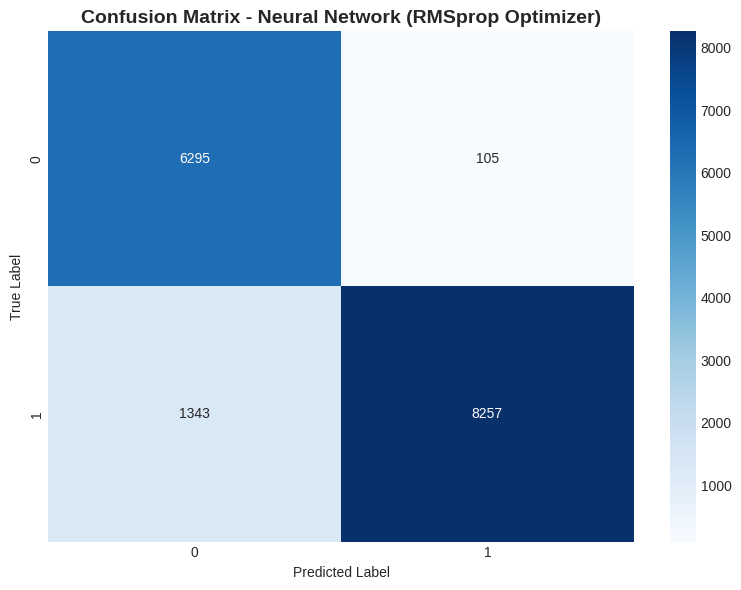

In [ ]:
#cm
cm_nn7 = confusion_matrix(y_val, y_val_pred_nn7)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_nn7,
    annot=True,
    fmt='d',
    cmap='Blues',   # different color map for clarity
    xticklabels=target_encoder.classes_,
    yticklabels=target_encoder.classes_
)
plt.title('Confusion Matrix - Neural Network (RMSprop Optimizer)', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()


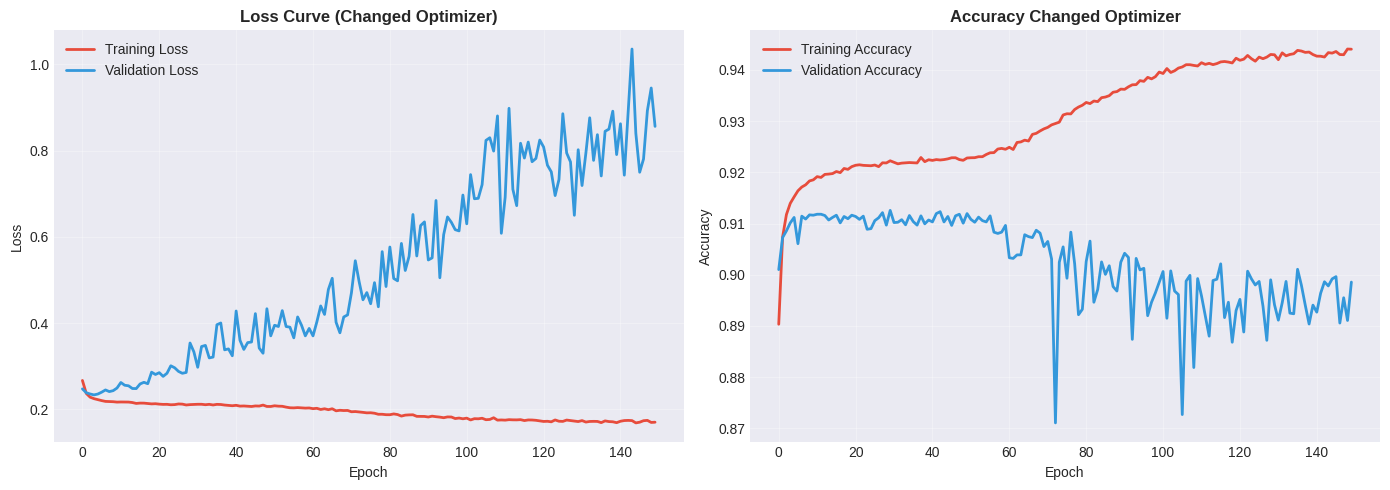


Model 7 — Best Validation Accuracy: 0.9126
Model 7 — Best Validation Loss: 0.2338


In [ ]:
# further visualizing the final iteration
plt.figure(figsize=(14, 5))

#loss curve
plt.subplot(1, 2, 1)
plt.plot(history7.history['loss'], label='Training Loss', linewidth=2, color='#e74c3c')
plt.plot(history7.history['val_loss'], label='Validation Loss', linewidth=2, color='#3498db')
plt.title('Loss Curve (Changed Optimizer)', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

#accuracy
plt.subplot(1, 2, 2)
plt.plot(history7.history['accuracy'], label='Training Accuracy', linewidth=2, color='#e74c3c')
plt.plot(history7.history['val_accuracy'], label='Validation Accuracy', linewidth=2, color='#3498db')
plt.title('Accuracy Changed Optimizer', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nModel 7 — Best Validation Accuracy: {max(history7.history['val_accuracy']):.4f}")
print(f"Model 7 — Best Validation Loss: {min(history7.history['val_loss']):.4f}")



MODEL 7: NEURAL NETWORK WITH RMSprop OPTIMIZER

Training Model 7 (RMSprop)...
Epoch 1/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8770 - loss: 0.2956 - val_accuracy: 0.8964 - val_loss: 0.2616
Epoch 2/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9089 - loss: 0.2351 - val_accuracy: 0.9080 - val_loss: 0.2390
Epoch 3/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9114 - loss: 0.2289 - val_accuracy: 0.9093 - val_loss: 0.2360
Epoch 4/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9128 - loss: 0.2265 - val_accuracy: 0.9103 - val_loss: 0.2383
Epoch 5/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9146 - loss: 0.2231 - val_accuracy: 0.9080 - val_loss: 0.2515
Epoch 6/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9164 - loss: 0.2208 - val_accuracy: 0.9104 - val_loss: 0.2356
Epoch 7/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9171 - loss: 0.2203 - val_accuracy: 0.9122 - val_loss: 0.2348
Epoch 8/50


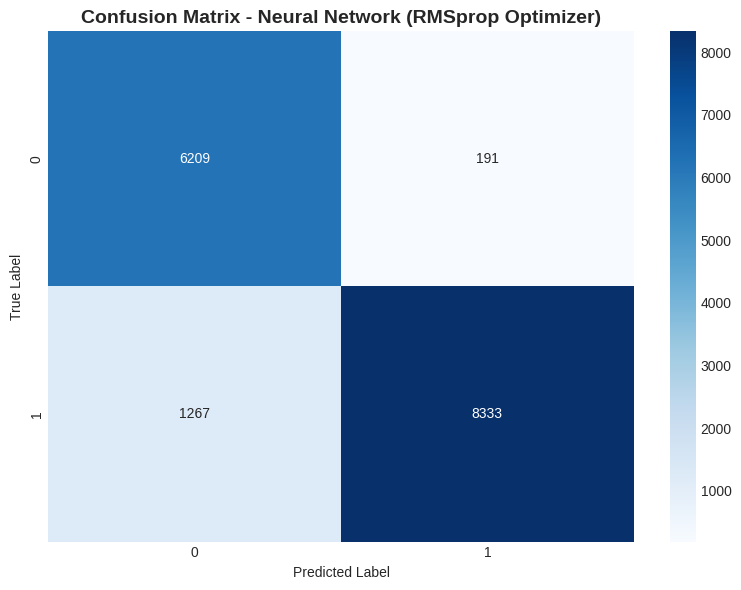

In [ ]:
# seeing if the model works approx the same with less epochs -- for Appendix
print("\n" + "="*70)
print("NN WITH RMSprop OPTIMIZER + Less Epochs")
print("="*70)

from tensorflow.keras.optimizers import RMSprop

def build_model7(input_dim, num_classes):
    model = keras.Sequential([
        layers.Dense(256, activation='relu', input_dim=input_dim),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=RMSprop(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

nn_model7 = build_model7(X_train_scaled.shape[1], len(np.unique(y)))

print("\nTraining")
history7 = nn_model7.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=32,
    verbose=1
)
#evaluate
y_val_pred_nn7 = np.argmax(nn_model7.predict(X_val_scaled), axis=1)

nn7_accuracy  = accuracy_score(y_val, y_val_pred_nn7)
nn7_precision = precision_score(y_val, y_val_pred_nn7, average='weighted')
nn7_recall    = recall_score(y_val, y_val_pred_nn7, average='weighted')
nn7_f1        = f1_score(y_val, y_val_pred_nn7, average='weighted')

print(f"\nValidation Set Performance (Model 7):")
print(f"  Accuracy:  {nn7_accuracy:.4f}")
print(f"  Precision: {nn7_precision:.4f}")
print(f"  Recall:    {nn7_recall:.4f}")
print(f"  F1-Score:  {nn7_f1:.4f}")

print("\nClassification Report — Model 7 (RMSprop):")
print(classification_report(y_val, y_val_pred_nn7))
#cm
cm_nn7 = confusion_matrix(y_val, y_val_pred_nn7)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_nn7,
    annot=True,
    fmt='d',
    cmap='Blues',   # different color map for clarity
    xticklabels=target_encoder.classes_,
    yticklabels=target_encoder.classes_
)
plt.title('Confusion Matrix - Neural Network (RMSprop Optimizer)', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()


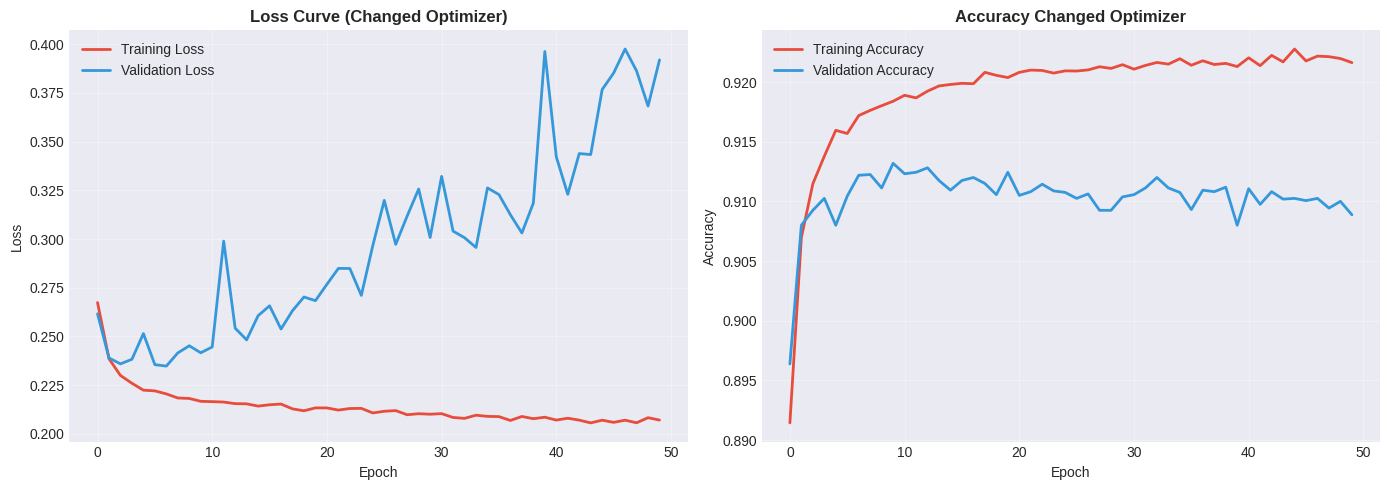


Model 7 — Best Validation Accuracy: 0.9132
Model 7 — Best Validation Loss: 0.2348


In [ ]:
# loss and accuracy curves for future reference portion, Appendix
plt.figure(figsize=(14, 5))

#loss curve
plt.subplot(1, 2, 1)
plt.plot(history7.history['loss'], label='Training Loss', linewidth=2, color='#e74c3c')
plt.plot(history7.history['val_loss'], label='Validation Loss', linewidth=2, color='#3498db')
plt.title('Loss Curve (Changed Optimizer)', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

#accuracy
plt.subplot(1, 2, 2)
plt.plot(history7.history['accuracy'], label='Training Accuracy', linewidth=2, color='#e74c3c')
plt.plot(history7.history['val_accuracy'], label='Validation Accuracy', linewidth=2, color='#3498db')
plt.title('Accuracy Changed Optimizer', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nModel 7 — Best Validation Accuracy: {max(history7.history['val_accuracy']):.4f}")
print(f"Model 7 — Best Validation Loss: {min(history7.history['val_loss']):.4f}")
